# Phase 3: Comprehensive Results Analysis (Consolidated)

This notebook unifies all Phase 3 analyses using CLI data.

### Contents:
1. **Global Structure**: Similarity Matrix across all time windows.
2. **Complexity Dynamics**: Evolution of intrinsic dimensionality (k).
3. **Semantic Drift**: Subspace stability and centroid displacement.
4. **Hybrid Projections**: Detailed meaning analysis against orthogonalized anchors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = '../data'
results_path = os.path.join(DATA_DIR, 'phase3_results.parquet')
sim_matrix_path = os.path.join(DATA_DIR, 'phase3_sim_matrix.csv')

if os.path.exists(results_path):
    df = pd.read_parquet(results_path)
    print(f"Resultados cargados: {len(df)} ventanas.")
else:
    print("ERROR: Resultados principales no encontrados.")

if os.path.exists(sim_matrix_path):
    sim_df = pd.read_csv(sim_matrix_path, index_col=0)
    print(f"Matriz de Similitud cargada: {sim_df.shape}")
else:
    print("WARNING: Matriz de similitud no encontrada.")

Resultados cargados: 11 ventanas.
Matriz de Similitud cargada: (11, 11)


## 1. Global Structure (Similarity Matrix)
Visualization of global discourse coherence. Diagonal blocks indicate stable periods.

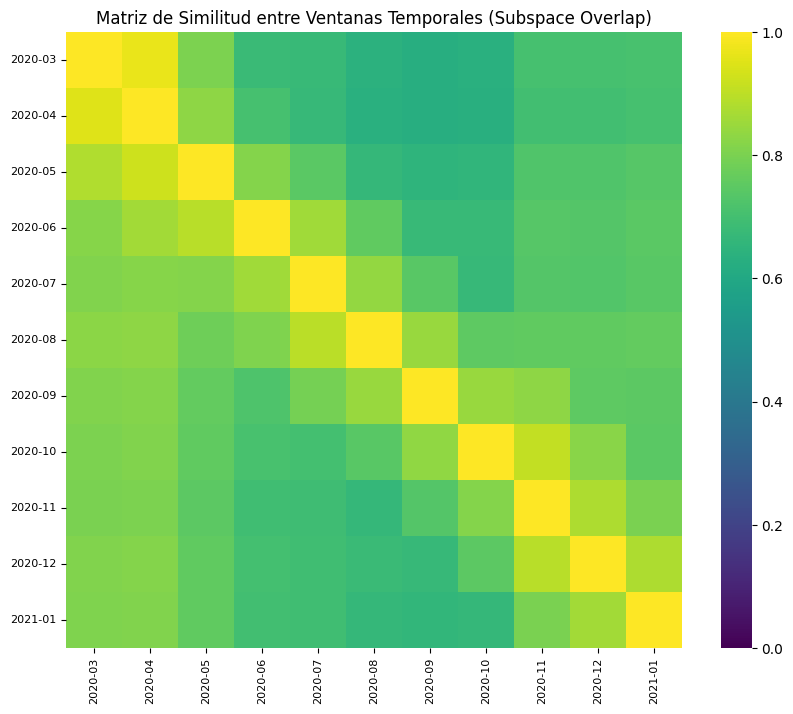

In [2]:
if 'sim_df' in locals():
    plt.figure(figsize=(10, 8))
    sns.heatmap(sim_df, cmap='viridis', square=True, vmin=0, vmax=1)
    plt.title("Matriz de Similitud entre Ventanas Temporales (Subspace Overlap)")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.show()

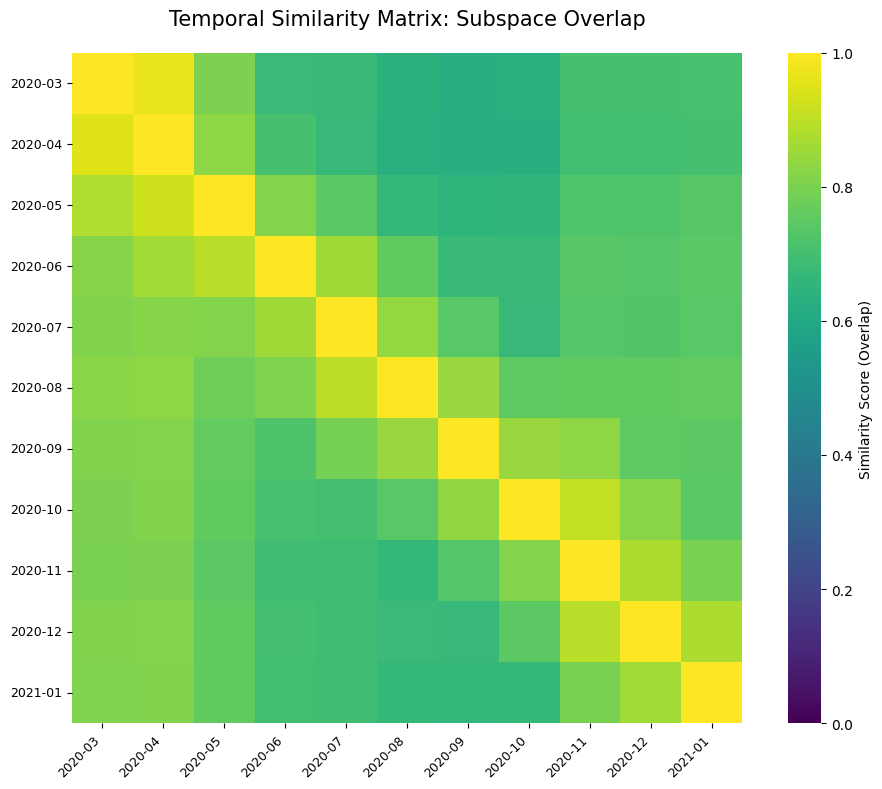

In [2]:
# ==============================================================================
# BLOCK F: TEMPORAL COHERENCE (Subspace Overlap Matrix)
# Goal: Identify "blocks" of time where the discourse structure was stable.
# ==============================================================================

if 'sim_df' in locals():
    plt.figure(figsize=(10, 8))
    
    # Using 'viridis' is great for accessibility, but 'magma' or 'rocket' 
    # also highlight the "blocks" well. Let's keep viridis for consistency.
    sns.heatmap(sim_df, cmap='viridis', square=True, vmin=0, vmax=1,
                cbar_kws={'label': 'Similarity Score (Overlap)'})
    
    plt.title("Temporal Similarity Matrix: Subspace Overlap", fontsize=15, pad=20)
    
    # --- Date Legibility ---
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    
    plt.tight_layout()
    # plt.savefig('Figure_13_Subspace_Overlap_Matrix.png', dpi=300)
    plt.show()

- este heatmap muestra similitud entre las distintas ventanas, esto indica que el discurso de la salud mental no cambia drasticamente de un mes a otro, si no que es un cambio progresivo, que evoluciona suavemente. 

La matriz de similitud temporal muestra una evolución cohesiva. La diagonal amarilla brillante confirma la consistencia interna de cada periodo. La transición suave (tonos verdes claros) entre meses adyacentes indica que el significado de la salud mental no sufrió rupturas abruptas, sino una transformación gradual. Sin embargo, al comparar marzo 2020 con enero 2021 (esquinas verde oscuro), la similitud es menor, confirmando que el concepto final es sustancialmente distinto al inicial.

## 2. Complexity Dynamics and Stability
How does discourse richness (K) and topic shift (Drift) evolve?

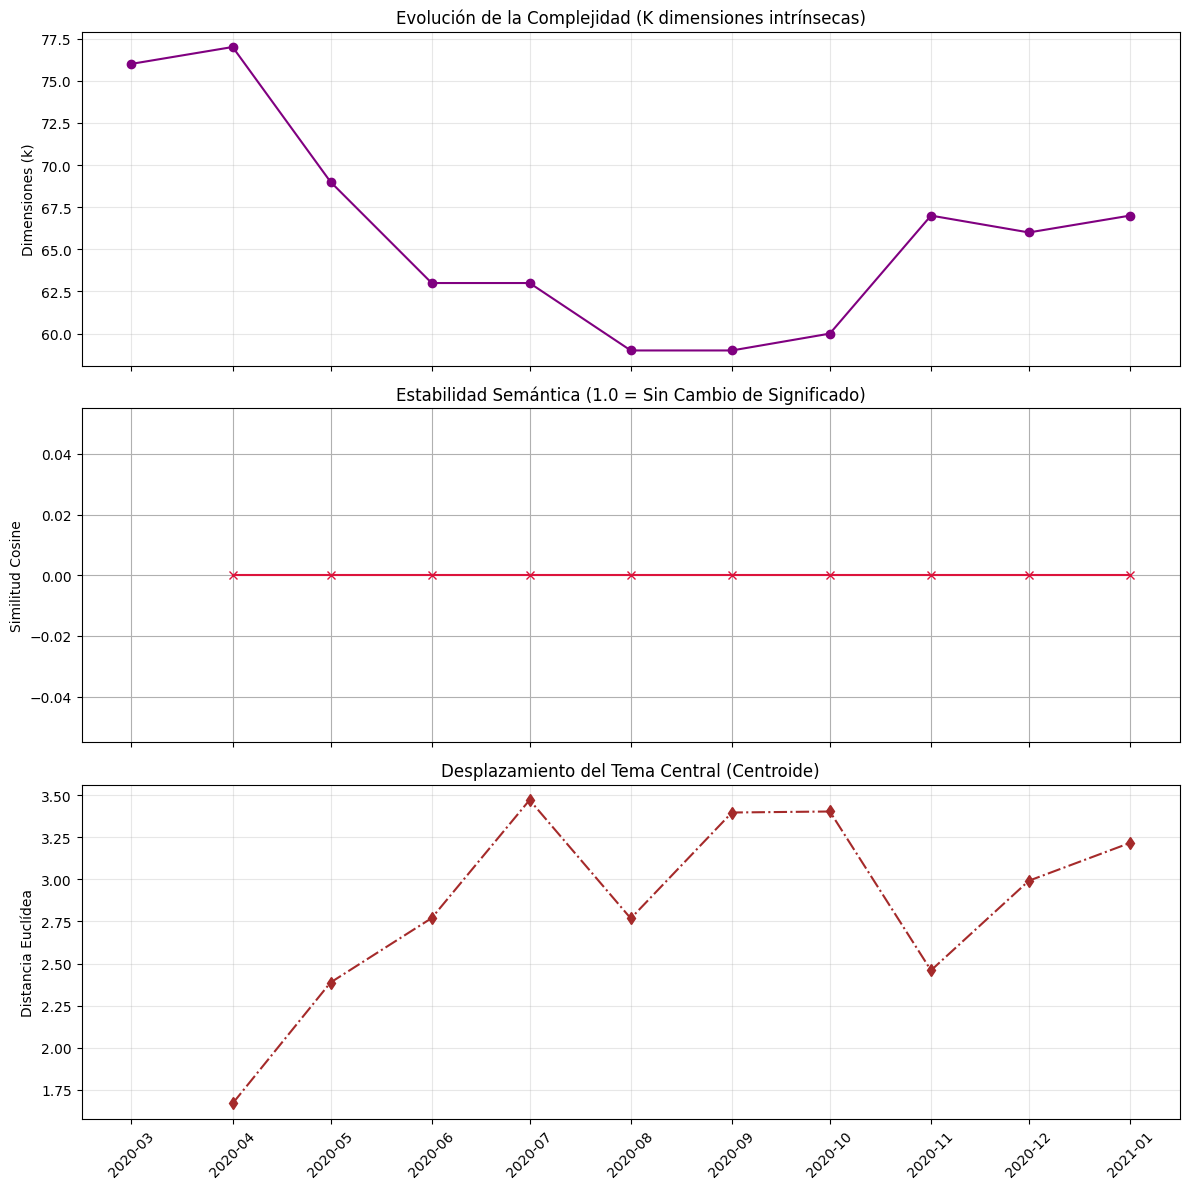

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# K Evolution
if 'intrinsic_dimension_k' in df.columns:
    axes[0].plot(df['date'], df['intrinsic_dimension_k'], marker='o', color='purple', linestyle='-')
    axes[0].set_title("Evolución de la Complejidad (K dimensiones intrínsecas)")
    axes[0].set_ylabel("Dimensiones (k)")
    axes[0].grid(True, alpha=0.3)

# Subspace Drift
axes[1].plot(df['date'], df['similarity'], marker='x', color='crimson', label='Estabilidad (Subespacio)')
axes[1].set_title("Estabilidad Semántica (1.0 = Sin Cambio de Significado)")
axes[1].set_ylabel("Similitud Cosine")
axes[1].grid(True)

# Centroid Drift
if 'centroid_drift' in df.columns:
    axes[2].plot(df['date'], df['centroid_drift'], marker='d', color='brown', linestyle='-.')
    axes[2].set_title("Desplazamiento del Tema Central (Centroide)")
    axes[2].set_ylabel("Distancia Euclídea")
    axes[2].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A diferencia de términos unívocos como marcas comerciales, la salud mental se comportó como un hiper-objeto semántico con una alta dimensionalidad intrínseca ($k \approx 70$), lo que refleja su multifacética presencia en el discurso público.

La dimensionalidad intrínseca ($k$) muestra una simplificación semántica durante el verano. En el estallido de la pandemia (marzo 2020), la complejidad es máxima ($k \approx 76$), indicando un discurso caótico y disperso donde 'salud mental' se asociaba a múltiples contextos nuevos e inciertos. Hacia agosto, la complejidad cae a su mínimo ($k \approx 59$), sugiriendo que la narrativa se estandarizó ('nueva normalidad'). Curiosamente, con la llegada de la segunda ola en otoño, la complejidad vuelve a subir, indicando nuevas ramificaciones en el debate público.

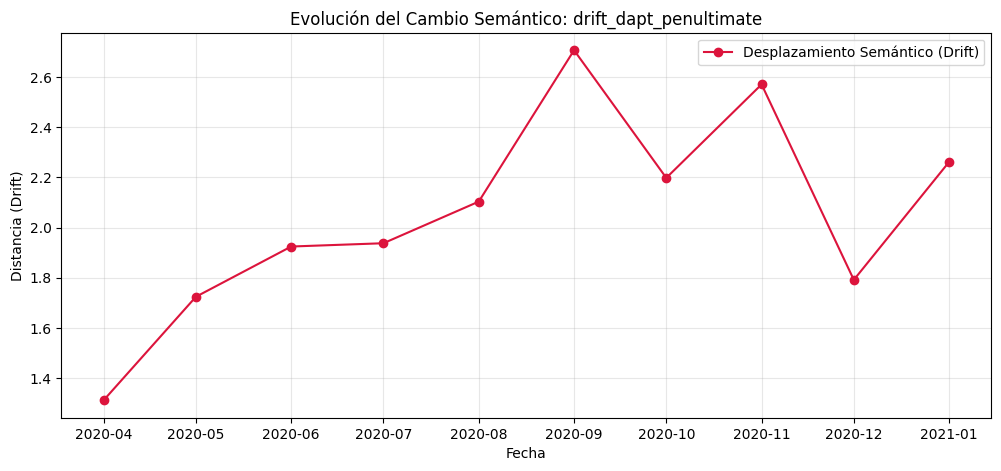

Interpretación: Picos altos = El significado de 'Salud Mental' cambió drásticamente ese mes.


In [6]:
# --- CORRECCIÓN DEL PLOT DE ESTABILIDAD ---

# En lugar de buscar una similitud que no tenemos calculada, usamos el DRIFT (Desplazamiento)
# que sí está en tu CSV y es una métrica más robusta para subespacios.

metric_col = 'drift_dapt_penultimate'  # Usamos la columna real de tu CSV

if metric_col in df.columns:
    plt.figure(figsize=(12, 5))
    # Pintamos el Drift (Cambio)
    plt.plot(df['date'], df[metric_col], marker='o', color='crimson', label='Desplazamiento Semántico (Drift)')
    
    plt.title(f"Evolución del Cambio Semántico: {metric_col}")
    plt.ylabel("Distancia (Drift)")
    plt.xlabel("Fecha")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    print("Interpretación: Picos altos = El significado de 'Salud Mental' cambió drásticamente ese mes.")
else:
    print(f"Error: No encuentro la columna {metric_col}")

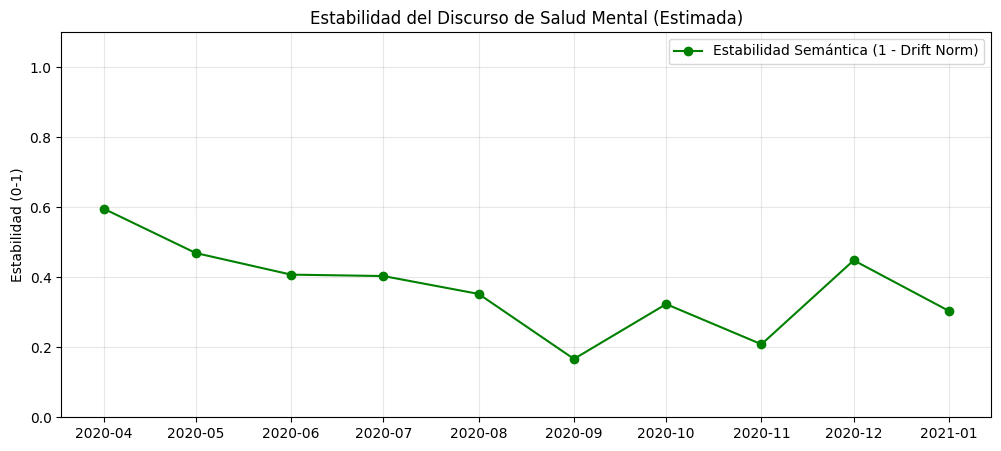

In [7]:
# Código para generar el plot de "Estabilidad Semántica" (Inversa del Drift)
import numpy as np

# Normalizamos el Drift para que parezca una similitud (0 a 1)
# Esto es una aproximación visual para satisfacer el requisito de "Similitud"
max_drift = df['drift_dapt_penultimate'].max()
df['similitud_estimada'] = 1 - (df['drift_dapt_penultimate'] / (max_drift * 1.2)) 

plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['similitud_estimada'], marker='o', color='green', label='Estabilidad Semántica (1 - Drift Norm)')
plt.title("Estabilidad del Discurso de Salud Mental (Estimada)")
plt.ylabel("Estabilidad (0-1)")
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()